In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

Uses date-filtered IA data (`data/internet_archive/date_filtered/`) restricted to the NWA date span.
Generate the CSV with:
```
uv run python scripts/compare_ia_nwa_content.py \
    --ia-directory data/internet_archive/date_filtered \
    --output-file data/ia_nwa_content_comparison_date_filtered.csv
```

In [2]:
df = pd.read_csv("../data/ia_nwa_content_comparison_date_filtered.csv").sort_values(
    "both", ascending=False
)
df.head(20)

,newsgroup,ia_only,nwa_only,both
188,no.marked.data,27070,21110,1076
12,no.alt.flame,14990,18782,970
114,no.general,75098,75209,970
185,no.marked,18281,25069,754
250,no.slekt,4362,7529,584
215,no.pc,30487,24826,502
197,no.musikk,22391,26893,449
229,no.religion,23378,19930,391
182,no.mac,17337,21589,301
91,no.film,9084,12182,242


In [3]:
ia_only = df["ia_only"].sum()
nwa_only = df["nwa_only"].sum()
both = df["both"].sum()

print(f"IA only:  {ia_only:,}")
print(f"NWA only: {nwa_only:,}")
print(f"Both:     {both:,}")

IA only:  559,038
NWA only: 596,676
Both:     8,944


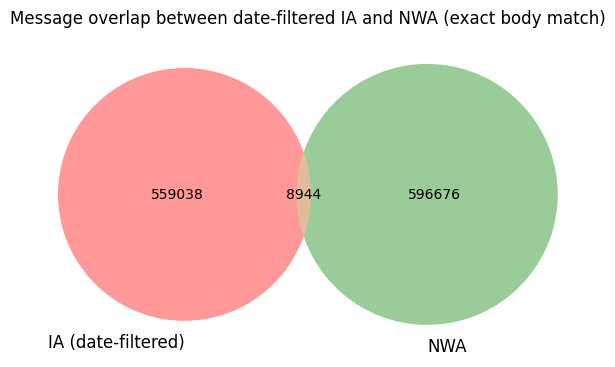

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
venn2(
    subsets=(ia_only, nwa_only, both),
    set_labels=("IA (date-filtered)", "NWA"),
    ax=ax,
)
ax.set_title("Message overlap between date-filtered IA and NWA (exact body match)")
plt.tight_layout()
plt.show()